In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [75]:
import pandas as pd
import numpy as np

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [77]:
#first impressions :)
#show_id - useless parameter
#mostly string based data (except release date)
#type is binary
#movie duration --> mins, show duration --> seasons (can use regex to normalize)
#Heavy null value count in director-- around 20 each in cast, country -- a few in date added, rating and duration as well
#     handling strategy --> replace NaN with ' ' for director, cast, country
#                       --> at max 17 colums with missing value for date, rating and duration --> safe to drop for now

In [78]:
df.dropna(subset=['duration', 'rating', 'date_added'], inplace=True)
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna(' ')
df.drop(columns=['show_id'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      8790 non-null   object
 3   cast          8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [79]:
#first normalizing pseudo-numerical data
df["duration"] = df["duration"].str.extract(r"(\d+)").astype("Int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      8790 non-null   object
 3   cast          8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   Int64 
 9   listed_in     8790 non-null   object
 10  description   8790 non-null   object
dtypes: Int64(1), int64(1), object(9)
memory usage: 832.6+ KB


In [80]:
df.describe()

,release_year,duration
count,8790.000000,8790.0
mean,2014.183163,69.934471
std,8.825466,50.794433
min,1925.000000,1.0
25%,2013.000000,2.0
50%,2017.000000,88.5
75%,2019.000000,106.0
max,2021.000000,312.0


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [81]:
#done above

## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [82]:
df['year_added'] = df['date_added'].str.extract(r'(\d{4})').astype('Int64')
df.drop('date_added', axis=1, inplace=True)

In [83]:
df.describe()

,release_year,duration,year_added
count,8790.000000,8790.0,8790.0
mean,2014.183163,69.934471,2018.873606
std,8.825466,50.794433,1.573568
min,1925.000000,1.0,2008.0
25%,2013.000000,2.0,2018.0
50%,2017.000000,88.5,2019.0
75%,2019.000000,106.0,2020.0
max,2021.000000,312.0,2021.0


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [84]:
top5 = df[df['type'] == 'Movie'].sort_values(
    by='duration', ascending=False
).head(5)

top5[['title', 'country', 'release_year', 'duration']]

,title,country,release_year,duration
4253,Black Mirror: Bandersnatch,United States,2018,312
717,Headspace: Unwind Your Mind,,2021,273
2491,The School of Mischief,Egypt,1973,253
2487,No Longer kids,Egypt,1979,237
2484,Lock Your Girls In,,1982,233


In [85]:
#the top 2 results may be wrong data entries
#blackmirror runs around 90 minutes IRL while headspace runs only 15 minutes (netflix special)

## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [86]:
df['type'].value_counts()

,count
type,
Movie,6126
TV Show,2664


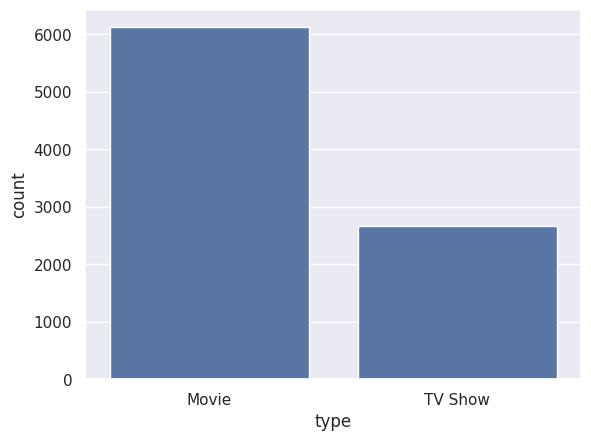

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='type')
plt.show()

clearly there are a lot more movies than shows

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [88]:
df[df['country'] != ' ']['country'].value_counts()

,count
country,
United States,2809
India,972
United Kingdom,418
Japan,243
South Korea,199
...,...
"Mexico, United States, Spain, Colombia",1
"Canada, Norway",1
"Finland, Germany, Belgium",1


In [89]:
#noticed how USA and UK are appearing in multiple rows
#this is due to groups of countries being treated as a whole string-- so each is listed seperately (thats not ideal)

#solution
#split wrt commas and explode into seperate columns (for now) -- then handle that data set

In [90]:
countries = (
    df[df['country'] != ' ']['country']
    .str.split(', ')
    .explode()
    .value_counts()
)

countries.head(5)

,count
country,
United States,3680
India,1046
United Kingdom,803
Canada,445
France,393


count for almost all countries has increased -- natrually

The number has spiked specifically for India as well

BUT- It is rare for Indian directors to collaborate internationally (from my limited knowledge of movies). So lets see how many times that has happened in this Dataset)

In [91]:
india_collabs = df[
    (df['country'].str.contains('India')) &
    (df['country'].str.contains(','))
]

print(len(india_collabs))

74


intresting :)

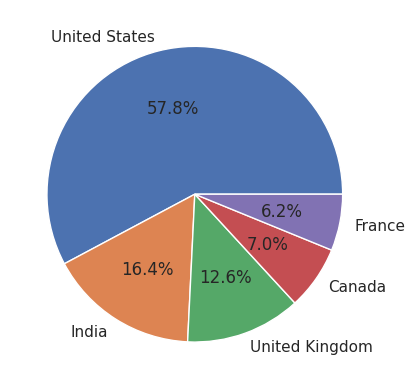

In [92]:
top5 = countries.head(5)
plt.pie(top5, labels=top5.index, autopct='%1.1f%%')
plt.show()

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [93]:
df['listed_in'] = df['listed_in'].str.split(', ')
df['country'] = df['country'].str.split(', ')

df = df.explode('listed_in').explode('country')

df['listed_in'] = df['listed_in'].str.strip()
df['country'] = df['country'].str.strip()
genreCountryCounts = (
    df[df['country'] != '']
    .groupby(['listed_in', 'country'])
    .size()
    .reset_index(name='count')
)



In [94]:
leading = (
    genreCountryCounts
    .loc[genreCountryCounts.groupby('listed_in')['count'].idxmax()]
    .reset_index(drop=True)
    .rename(columns={'listed_in': 'genre', 'country': 'leading_country'})
    .sort_values('genre')
)

print(leading.to_string(index=False))

                       genre leading_country  count
          Action & Adventure   United States    404
              Anime Features           Japan     61
                Anime Series           Japan    141
            British TV Shows  United Kingdom    224
    Children & Family Movies   United States    390
           Classic & Cult TV   United States     15
              Classic Movies   United States     81
                    Comedies   United States    680
              Crime TV Shows   United States    145
                 Cult Movies   United States     52
               Documentaries   United States    511
                  Docuseries   United States    191
                      Dramas   United States    835
        Faith & Spirituality   United States     42
               Horror Movies   United States    201
          Independent Movies   United States    390
        International Movies           India    864
      International TV Shows     South Korea    152
            

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

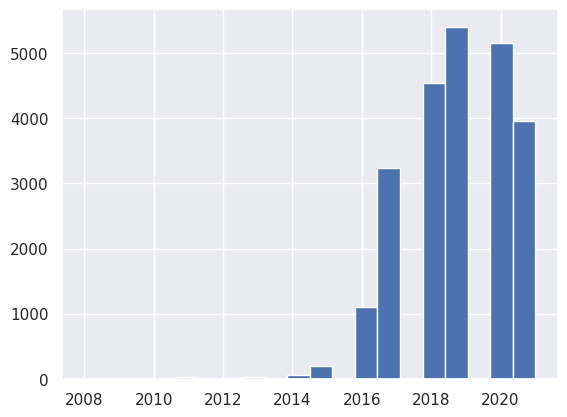

In [95]:
plt.hist(df['year_added'], bins=20)
plt.show()

2019 has slightly over 2000 releases making it the busiest year

followed closely by 2020 with aroud 1850 releases

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

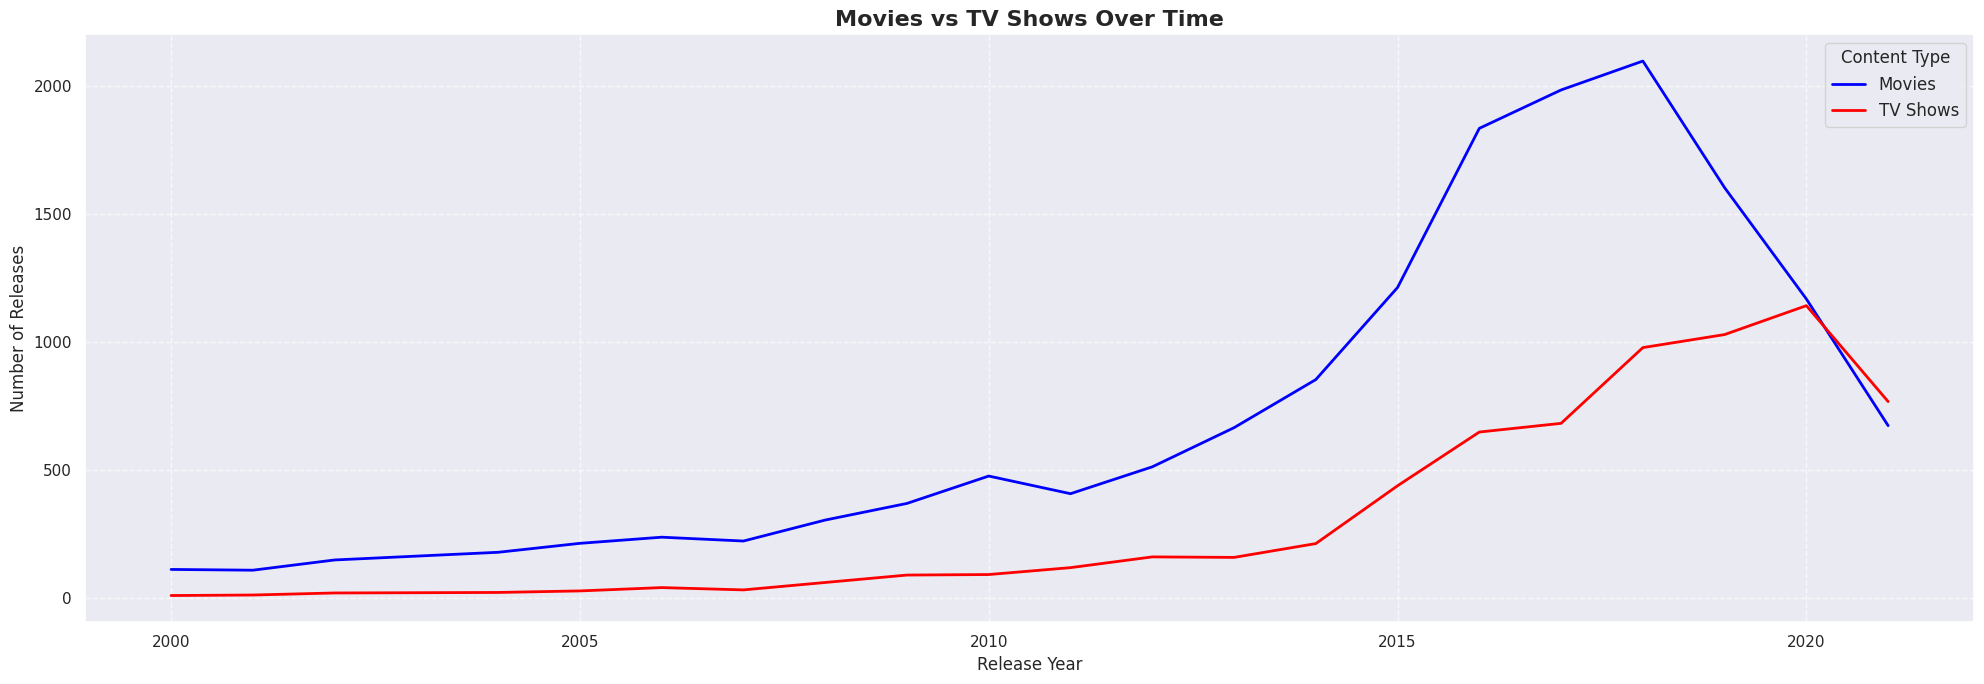

In [100]:
yearly_counts = df[df.release_year >= 2000].groupby(['release_year', 'type']).size().unstack(fill_value=0)


plt.figure(figsize=(20, 7))

plt.plot(yearly_counts.index, yearly_counts['Movie'], label='Movies', color='blue', linewidth=2)
plt.plot(yearly_counts.index, yearly_counts['TV Show'], label='TV Shows', color='red', linewidth=2)

plt.title('Movies vs TV Shows Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Content Type', fontsize=12)
plt.tight_layout()
plt.show()

Naturally movies have always dominated in number
But -- Looking at the end of the graph, that tide may be turning
In recent years (post 2020), the show releases have slightly overtaken movie releases

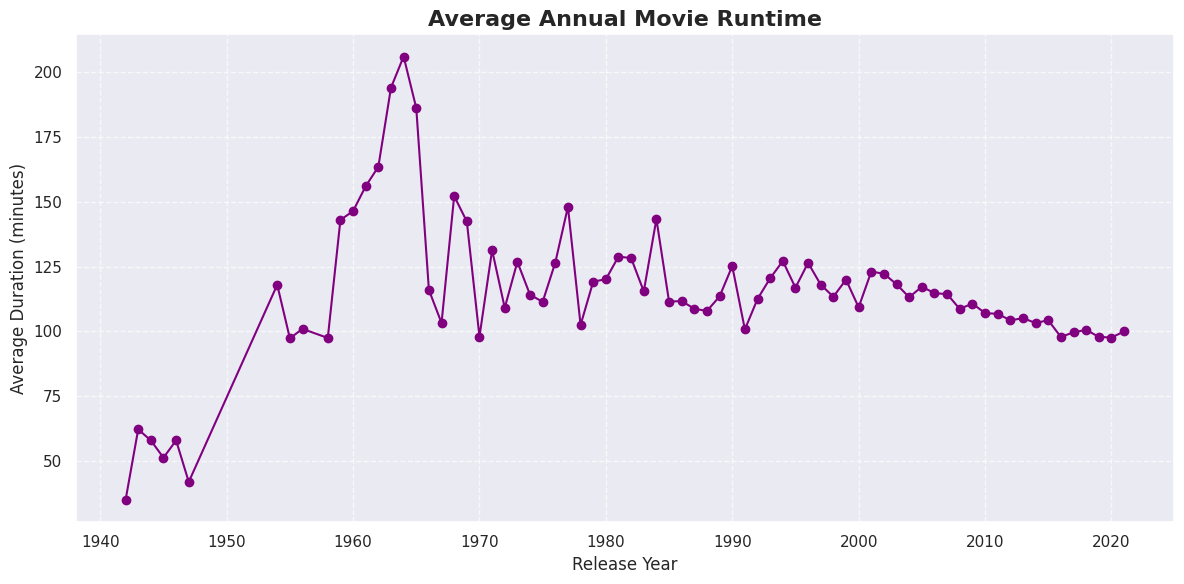

In [101]:
df_movies = df[df['type'] == 'Movie']

avg_movie_runtime = df_movies.groupby('release_year')['duration'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(avg_movie_runtime['release_year'], avg_movie_runtime['duration'], marker='o', linestyle='-', color='purple')
plt.title('Average Annual Movie Runtime', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A downward trend is noticable in the Runtimes. Possible causes may be :
1) Smaller attention spans in modern audiences
2) Netflix endorsing large number of short films, thus pulling the average down

There is a rather sharp spike around 1965.These may be documentries


But no definative statements can be made from one plot alone

In [ ]:
#I have also tried to explore Indian collaborations with foreign countries above in line 91